In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import os, json

I0000 00:00:1781645153.993765 3560095 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
# Check image path

omama_dir_path = "/hpcstor6/scratch01/a/anya.tongprasith001/U54REC/omama/2d_resized_256/images"
if not os.path.exists(omama_dir_path):
    print(f"File not found: {omama_dir_path}")
    print("Please update dicom_path with a valid image file path")
else:
    print(f"Found DICOM folder: {os.path.basename(omama_dir_path)}")
    omama_folder = Path("/hpcstor6/scratch01/a/anya.tongprasith001/U54REC/omama/2d_resized_256/images")
    IDs = sorted(str(file) for file in omama_folder.rglob("*.npz"))
    print(len(IDs))

Found DICOM folder: images
163568


In [4]:
meta_dir = Path("/hpcstor6/scratch01/a/anya.tongprasith001/U54REC/omama/2d_resized_256/metadata")

In [5]:
# Normalize the images
all_images = []
all_labels = []

for ID in IDs :
    meta = json.load(open(meta_dir / f"{Path(ID).stem}.json"))
    if meta["label"] == "NonCancer" :
        all_labels.append(0)
    elif meta["label"] == "Unknown" :
        continue
    elif meta["label"] == "IndexCancer" or meta["label"] == "PreIndexCancer" : 
        all_labels.append(1)
    else : 
        continue
    img = np.load(ID)['data']
    img = img.astype("float32") / 255.0 # Normalize to 0-1
    img = np.expand_dims(img, axis=-1)
    all_images.append(img)
    

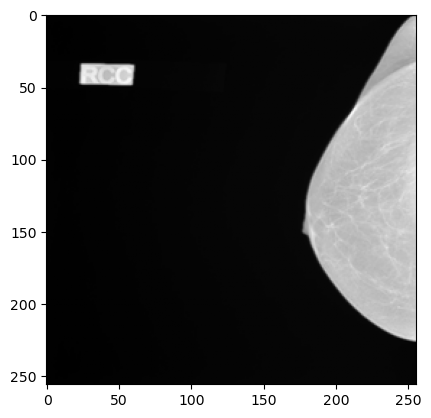

In [6]:
plt.imshow(all_images[0], cmap='gray')

In [7]:
# Split data
train_size = int(0.7 * len(all_images))
val_size = int(0.01 * len(all_images))
test_size = int(0.01 * len(all_images))

train_images = all_images[:train_size]
val_images = all_images[train_size:val_size + train_size]
test_images = all_images[val_size + train_size:val_size + train_size + test_size]

train_labels = all_labels[:train_size]
val_labels = all_labels[train_size:val_size + train_size]
test_labels = all_labels[val_size + train_size:val_size + train_size + test_size]

print(f"Train: {len(train_images)}, Val: {len(val_images)}, Test: {len(test_images)}")
print(f"Train: {len(train_labels)}, Val: {len(val_labels)}, Test: {len(test_labels)}")

Train: 113112, Val: 1615, Test: 1615
Train: 113112, Val: 1615, Test: 1615


In [8]:
# Convert to NumPy array
train_images = np.array(train_images, dtype=np.float32)
val_images = np.array(val_images, dtype=np.float32)
test_images = np.array(test_images, dtype=np.float32)

train_labels = np.array(train_labels, dtype=np.float32)
val_labels = np.array(val_labels, dtype=np.float32)
test_labels = np.array(test_labels, dtype=np.float32)

In [9]:
# Check the number of non-cancer vs cancer cases
from collections import Counter
print("train", Counter(train_labels.astype(int)))
print("val", Counter(val_labels.astype(int)))
print("test", Counter(test_labels.astype(int)))

train Counter({np.int64(0): 111129, np.int64(1): 1983})
val Counter({np.int64(0): 1566, np.int64(1): 49})
test Counter({np.int64(0): 1565, np.int64(1): 50})


In [10]:
# Create balanced train dataset
images = []
labels = []
NonCancer = 0
Cancer = 0
for img, label in zip(train_images, train_labels) :
    if NonCancer == 1983 and Cancer == 1983 :
        break
    if NonCancer < 1983 and label == 0 :
        images.append(img)
        labels.append(label)
        NonCancer += 1
    elif Cancer < 1983 and label == 1 :
        images.append(img)
        labels.append(label)
        Cancer += 1
train_images = np.array(images, dtype=np.float32)
train_labels = np.array(labels, dtype=np.float32)
print("train", Counter(train_labels.astype(int)))

train Counter({np.int64(0): 1983, np.int64(1): 1983})


In [11]:
# Check dimension size and color channel
print("Shape:", all_images[0].shape)

Shape: (256, 256, 1)


In [12]:
# Create the dataset and group into batches
train_ds = tf.data.Dataset.from_tensor_slices((train_images, train_labels))
train_ds = train_ds.batch(32)

val_ds = tf.data.Dataset.from_tensor_slices((val_images, val_labels))
val_ds = val_ds.batch(32)

test_ds = tf.data.Dataset.from_tensor_slices((test_images, test_labels))
test_ds = test_ds.batch(32)

I0000 00:00:1781645402.968215 3560095 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 38380 MB memory:  -> device: 0, name: NVIDIA A100-SXM4-40GB, pci bus id: 0000:b7:00.0, compute capability: 8.0


In [13]:
# Configure dataset performance
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

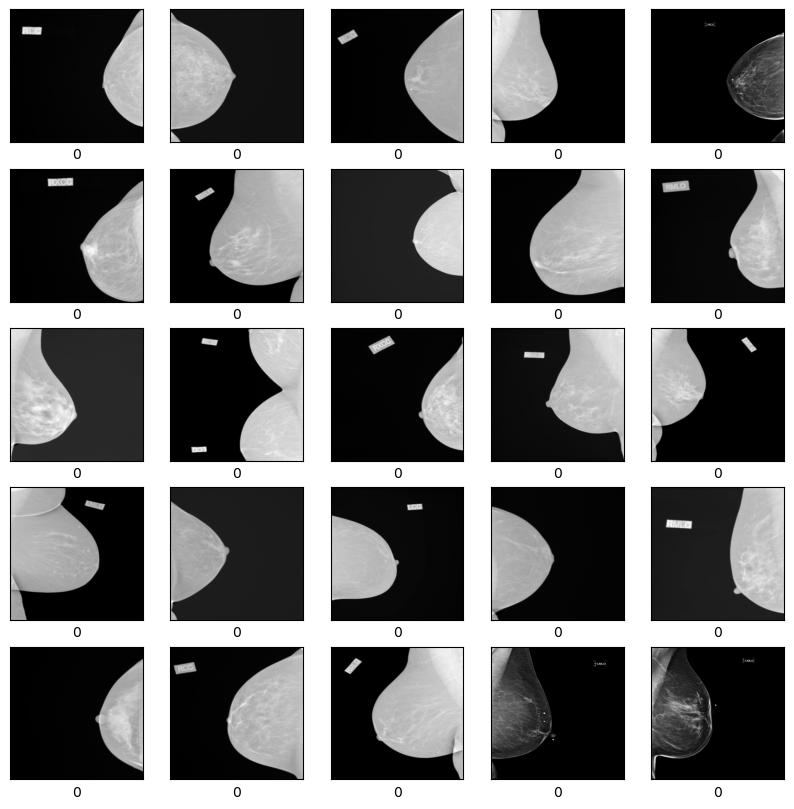

In [14]:
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(all_images[i], cmap='gray')
    plt.xlabel(all_labels[i])
plt.show()

In [15]:
# Create convolutional base
model = models.Sequential()
model.add(layers.Input(shape=(256, 256, 1))),
model.add(layers.Conv2D(32, 3, activation='relu')),
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))

In [16]:
# Add Dense layers on top
model.add(layers.GlobalAveragePooling2D())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

In [17]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59,969 (234.25 KB)

 Trainable params: 59,969 (234.25 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
model.compile(optimizer='adam',
              loss = 'binary_crossentropy',
              metrics = ['accuracy']
             )
history = model.fit(train_ds, epochs = 10,
                    validation_data=val_ds, shuffle=True)

Epoch 1/10


I0000 00:00:1781645424.231324 3607842 service.cc:153] XLA service 0x7f1864047d20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781645424.231353 3607842 service.cc:161]   StreamExecutor [0]: NVIDIA A100-SXM4-40GB, Compute Capability 8.0 (Driver: 12.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.23.2)
I0000 00:00:1781645424.299348 3607842 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1781645424.619520 3607842 cuda_dnn.cc:461] Loaded cuDNN version 92302
I0000 00:00:1781645424.652903 3607842 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2028__.29
Could not load symbol cuFuncGetName. Error: /usr/lib/x86_64-linux-gnu/libcuda.so.1: undefined symbol: cuFuncGetName
I0000 00:00:1781645426.381694 3607842 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does no

 13/124 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7532 - loss: 0.6325

I0000 00:00:1781645439.227212 3607842 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


123/124 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8824 - loss: 0.4106

I0000 00:00:1781645440.875599 3607842 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2028__.29
I0000 00:00:1781645441.617951 3607842 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1781645444.256167 3608579 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_8', 96 bytes spill stores, 96 bytes spill loads

I0000 00:00:1781645445.496686 3607842 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1781645447.888050 3608578 subprocess_compilation.cc:348] ptxas warning : Registers are spilled 

124/124 ━━━━━━━━━━━━━━━━━━━━ 35s 155ms/step - accuracy: 0.8752 - loss: 0.4199 - val_accuracy: 0.0303 - val_loss: 9.1518
Epoch 2/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.4410 - loss: 1.2108 - val_accuracy: 0.0303 - val_loss: 0.8664
Epoch 3/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.5154 - loss: 0.6288 - val_accuracy: 0.0303 - val_loss: 4.1016
Epoch 4/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.3487 - loss: 0.9361 - val_accuracy: 0.0303 - val_loss: 0.7674
Epoch 5/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.3654 - loss: 0.7072 - val_accuracy: 0.0303 - val_loss: 0.7520
Epoch 6/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.3525 - loss: 0.7052 - val_accuracy: 0.0303 - val_loss: 0.7409
Epoch 7/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.4291 - loss: 0.6933 - val_accuracy: 0.0303 - val_loss: 0.7982
Epoch 8/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.3422 - loss: 0.7155 - val_accuracy: 0.0

51/51 - 0s - 6ms/step - accuracy: 0.0310 - loss: 0.7235


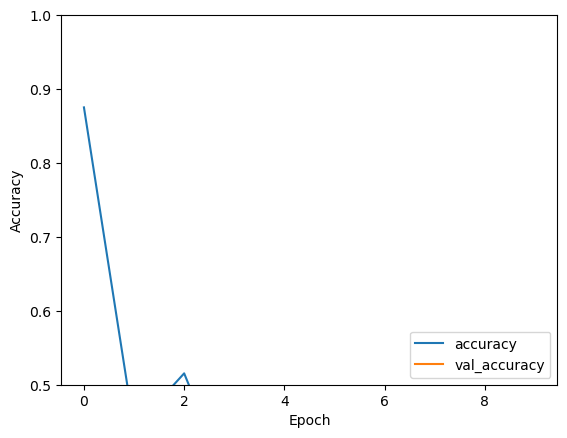

In [19]:
# Evaluate model
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')

test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)

In [20]:
print(test_acc)

0.030959751456975937


In [21]:
model.evaluate(test_ds)

51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0310 - loss: 0.7235


[0.7235053181648254, 0.030959751456975937]